# Test Data Loading

In [1]:
import cma

### Vessel Data

In [2]:
vessels_pool = cma.read_vessel_class_data()
vessels_pool

       Vessel Type  Vessel Number
0    Rank 1 Vessel             21
1    Rank 2 Vessel             41
2    Rank 3 Vessel             62
3    Rank 4 Vessel             71
4    Rank 5 Vessel             86
5    Rank 6 Vessel             39
6    Rank 7 Vessel             68
7    Rank 8 Vessel             54
8    Rank 9 Vessel             57
9   Rank 10 Vessel             48
10  Rank 11 Vessel             25
11  Rank 12 Vessel             36
12  Rank 13 Vessel             11

### Port Data

In [3]:
portpool = None
_, portpool = cma.read_port_data()
print(portpool.get_number_of_ports())

93


In Total  92  ports are plotted


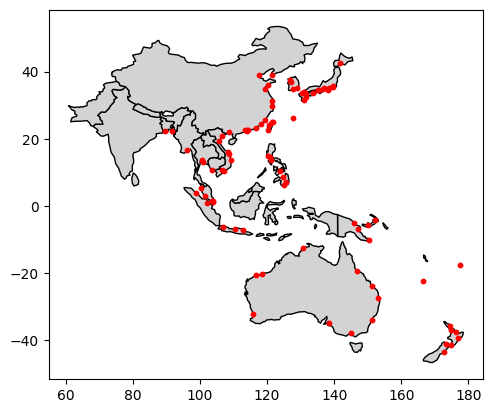

In [4]:
asia_pacific_countries = [
	'China','Taiwan', 'Japan', 'South Korea',
	'Vietnam', 'Myanmar', 'Laos', 'Thailand', 'Cambodia',
	'Indonesia', 'Philippines', 'Malaysia', 'Singapore', 'Brunei', 'Timor-Leste',
	'Pakistan', 'India', 'Bangladesh', 'Sri Lanka', 'Nepal','Maldives',
	'Australia', 'Papua New Guinea', 'New Zealand', 'Solomon Islands',
	'Vanuatu', 'Samoa', 'Tonga', 'Tuvalu', 'Nauru', 'Palau', 'Marshall Islands','Kiribati' #, 'Fiji'
]
_, ax, portpool_selected = portpool.plot(asia_pacific_countries, plot_port_id = False)

In [5]:
port_PHMNL = portpool_selected.get_port_by_name('PHMNL')
port_PHMNL.get_port_call_costs(vessels_pool)

[inf, 3, 4, 218, 81, 94, 213, 1, inf, inf, inf, inf, inf]

In [6]:
print('Ports filtered by Max Draft')
print(0, len(portpool_selected.filter_by_max_draft(0)))
print(5, len(portpool_selected.filter_by_max_draft(5)))
print(10, len(portpool_selected.filter_by_max_draft(10)))
print(15, len(portpool_selected.filter_by_max_draft(15)))
print(20, len(portpool_selected.filter_by_max_draft(20)))
print(25, len(portpool_selected.filter_by_max_draft(25)))
print(30, len(portpool_selected.filter_by_max_draft(30)))

Ports filtered by Max Draft
0 92
5 92
10 83
15 57
20 40
25 40
30 39


In [7]:
print('Ports filtered by Transshipment Cost')
print(1000, len(portpool_selected.filtered_by_transship_cost(1000)))
print(500, len(portpool_selected.filtered_by_transship_cost(500)))
print(250, len(portpool_selected.filtered_by_transship_cost(250)))
print(125, len(portpool_selected.filtered_by_transship_cost(125)))
print(75, len(portpool_selected.filtered_by_transship_cost(75)))

Ports filtered by Transshipment Cost
1000 92
500 90
250 84
125 64
75 45


### Current Lines Data

In [8]:
current_lines, _ = cma.read_current_line_data(portpool_selected)

How many lines? 46
Example:
A3CANL -- [TWKHH, CNXMN, CNSHA, CNNGB, AUSYD, AUMEL, AUBNE]


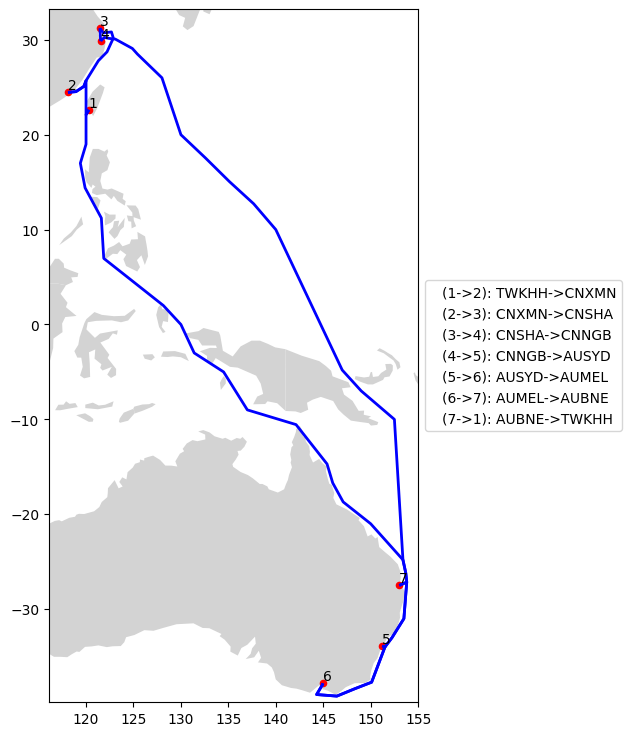

In [9]:
print('How many lines?', len(current_lines))
print('Example:')
line_0 = current_lines[0]
print(line_0)
line_0.plot(asia_pacific_countries)

### Service Graph

In [10]:
# distance data
dist_mat = cma.read_sailing_distance_data(portpool_selected)

# demand data
demands_dict, total_weekly_demand_mat = cma.read_demand_data(portpool_selected)
# this is not a dense matrix but a sparse matrix
(total_weekly_demand_mat > 0).sum()

/Users/linsheng/Documents/GitHub/nus_cma_project/src/cma/data_reader.py:129: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(str(file))  # read first table


1505

In [11]:
# create a collection of ports
portgraph = cma.PortGraph(portpool_selected, dist_mat, total_weekly_demand_mat)
# create the current servicelines graph
servicegraph = cma.ServiceGraph(current_lines)

In [12]:
# Use other criterions to filter transship hubs
trans_ports_1 = portgraph.filter_by_max_draft(15)
trans_ports_2 = portgraph.filtered_by_transship_cost(100)
trans_ports = list(set(trans_ports_1) & set(trans_ports_2))
len(trans_ports)

31

In [13]:
# Use transshipment capacity
trans_ports = portgraph.filtered_by_transship_capacity()
len(trans_ports)

12

In [14]:
od_pairs_dict = servicegraph.get_all_paths(portgraph, trans_ports)
od_pairs = od_pairs_dict['od_pairs']
od_pairs_paths = od_pairs_dict['od_pairs_path']
od_pairs_demand = od_pairs_dict['od_pairs_demand']
unconnected = od_pairs_dict['unconnected']
unconnected_demand = od_pairs_dict['unconnected_demand']

num_all_paths = 0
for pair, paths in zip(od_pairs, od_pairs_paths):
	num_all_paths += len(paths)
print(od_pairs_demand)
print(len(od_pairs))
print(num_all_paths)
print(len(unconnected))
print(sum(unconnected_demand), sum(od_pairs_demand))

[858.0, 852.0, 794.0, 755.0, 666.0, 651.0, 627.0, 613.0, 600.0, 563.0, 555.0, 532.0, 524.0, 483.0, 449.0, 446.0, 438.0, 434.0, 424.0, 408.0, 408.0, 408.0, 380.0, 370.0, 355.0, 354.0, 342.0, 340.0, 338.0, 329.0, 328.0, 324.0, 323.0, 321.0, 320.0, 309.0, 304.0, 302.0, 293.0, 285.0, 279.0, 271.0, 267.0, 266.0, 263.0, 262.0, 259.0, 253.0, 252.0, 246.0, 243.0, 236.0, 233.0, 233.0, 233.0, 232.0, 230.0, 224.0, 223.0, 221.0, 219.0, 219.0, 218.0, 217.0, 207.0, 203.0, 201.0, 200.0, 192.0, 191.0, 189.0, 189.0, 187.0, 186.0, 186.0, 183.0, 182.0, 178.0, 178.0, 178.0, 178.0, 177.0, 176.0, 175.0, 175.0, 172.0, 170.0, 169.0, 166.0, 163.0, 161.0, 158.0, 158.0, 157.0, 155.0, 154.0, 154.0, 152.0, 151.0, 149.0, 148.0, 147.0, 146.0, 145.0, 142.0, 141.0, 140.0, 139.0, 138.0, 138.0, 137.0, 136.0, 134.0, 133.0, 133.0, 131.0, 130.0, 130.0, 129.0, 129.0, 128.0, 128.0, 128.0, 128.0, 127.0, 126.0, 126.0, 124.0, 124.0, 124.0, 124.0, 122.0, 121.0, 120.0, 119.0, 118.0, 117.0, 115.0, 114.0, 113.0, 112.0, 112.0, 112.0

In [15]:
week_levels= (1/2, 1, 2, 3, 4, 5, 6, 7, 8, 9)
n_od_pairs = 0
sol = servicegraph.fulfill_demands(od_pairs[:n_od_pairs], od_pairs_paths[:n_od_pairs], portgraph, vessels_pool)
sol['total cost']

0.0

In [16]:
line_weeks = sol['weeks'].value @ week_levels
ship_vars = sol['ships']

print('Line Name', ' \t', 'distance', '\t', 'week', '\t', 'sailing-days', '\t', 'ships')
for line, week, days, line_ships in zip(current_lines, line_weeks, sol['line sailing days'], ship_vars):
	line_ships_val = [int(ship.value) for ship in line_ships]
	print(
		line.name(), ' \t',
		int(line.get_distance(portgraph)), '\t\t',
		int(week), '\t',
		round(days.value, 2),'\t\t',
		line_ships_val)

Line Name  	 distance 	 week 	 sailing-days 	 ships
A3CANL  	 10710 		 6 	 42.0 		 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
A3NANL  	 12728 		 4 	 28.0 		 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
A3SANL  	 10424 		 4 	 28.0 		 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
AAXEANL  	 10494 		 5 	 35.0 		 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
AAXSANL  	 9655 		 5 	 35.0 		 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
AAXWANL  	 5026 		 2 	 14.0 		 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
ANZANL  	 3226 		 2 	 14.0 		 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
ANZXANL  	 13516 		 6 	 42.0 		 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
BBX2CNC  	 7892 		 3 	 21.0 		 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
BBX3CNC  	 7172 		 3 	 21.0 		 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
BBX6CNC  	 8430 		 5 	 35.0 		 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
BBXCNC  	 3002 		 1 	 7.0 		 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
CHN1CNC  	 5994 		 2 	 14.0 		 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
CMS2CNC  	 5559 		 2 	 14.